# Лабораторная работа №7: Симуляция импульсных нейронных сетей

**Тема дипломной работы:** Информационная система контроля дефектов закупорки молочной тары  
**Платформа:** Apple Silicon M3 Pro (MPS → CPU fallback)  
**Фреймворк:** snntorch + PyTorch

---

## 0. Установка зависимостей

Выполните в терминале из папки `week7/`:
```bash
pip install -r requirements.txt
```

In [1]:
import sys, os
# Добавляем week7/ в путь поиска модулей
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import snntorch as snn

print(f'Python:   {sys.version.split()[0]}')
print(f'PyTorch:  {torch.__version__}')
print(f'snntorch: {snn.__version__}')
print(f'MPS available: {torch.backends.mps.is_available()}')

Python:   3.10.11
PyTorch:  2.4.1
snntorch: 0.7.0
MPS available: True


In [2]:
from src.snn.snn_classifier import get_device
DEVICE = get_device()
print(f'Используемое устройство: {DEVICE}')

Используемое устройство: mps


---
## 1. Задача 2: LIF-нейрон

Реализуем и визуализируем динамику LIF-нейрона для разных сигналов датчиков линии закупорки.

In [3]:
from src.snn.lif_neuron import LIFNeuron, LIFNeuronConfig, generate_sensor_signal, plot_lif_dynamics

# Создаём нейрон с настраиваемыми параметрами
config = LIFNeuronConfig(
    beta=0.9,          # коэффициент утечки
    threshold=1.0,     # порог срабатывания
    reset_mechanism='zero',
    num_timesteps=25
)
neuron = LIFNeuron(config)
print('LIF-нейрон создан')
print(f'  beta      = {config.beta}')
print(f'  threshold = {config.threshold}')
print(f'  reset     = {config.reset_mechanism}')

LIF-нейрон создан
  beta      = 0.9
  threshold = 1.0
  reset     = zero


In [4]:
# Симуляция для каждого типа дефекта
print('Тип сигнала       | Спайков | Ср. потенциал')
print('-' * 48)
for sig_type in ['normal', 'pressure', 'vibration', 'leak']:
    signal = generate_sensor_signal(sig_type, duration=100, seed=42)
    with torch.no_grad():
        spikes, mem = neuron.simulate(signal)
    print(f'  {sig_type:<16} | {int(spikes.sum()):>7} | {mem.mean():.4f}')

Тип сигнала       | Спайков | Ср. потенциал
------------------------------------------------
  normal           |      18 | 0.5780
  pressure         |       6 | 0.2411
  vibration        |      24 | 0.4841
  leak             |      37 | 0.7029


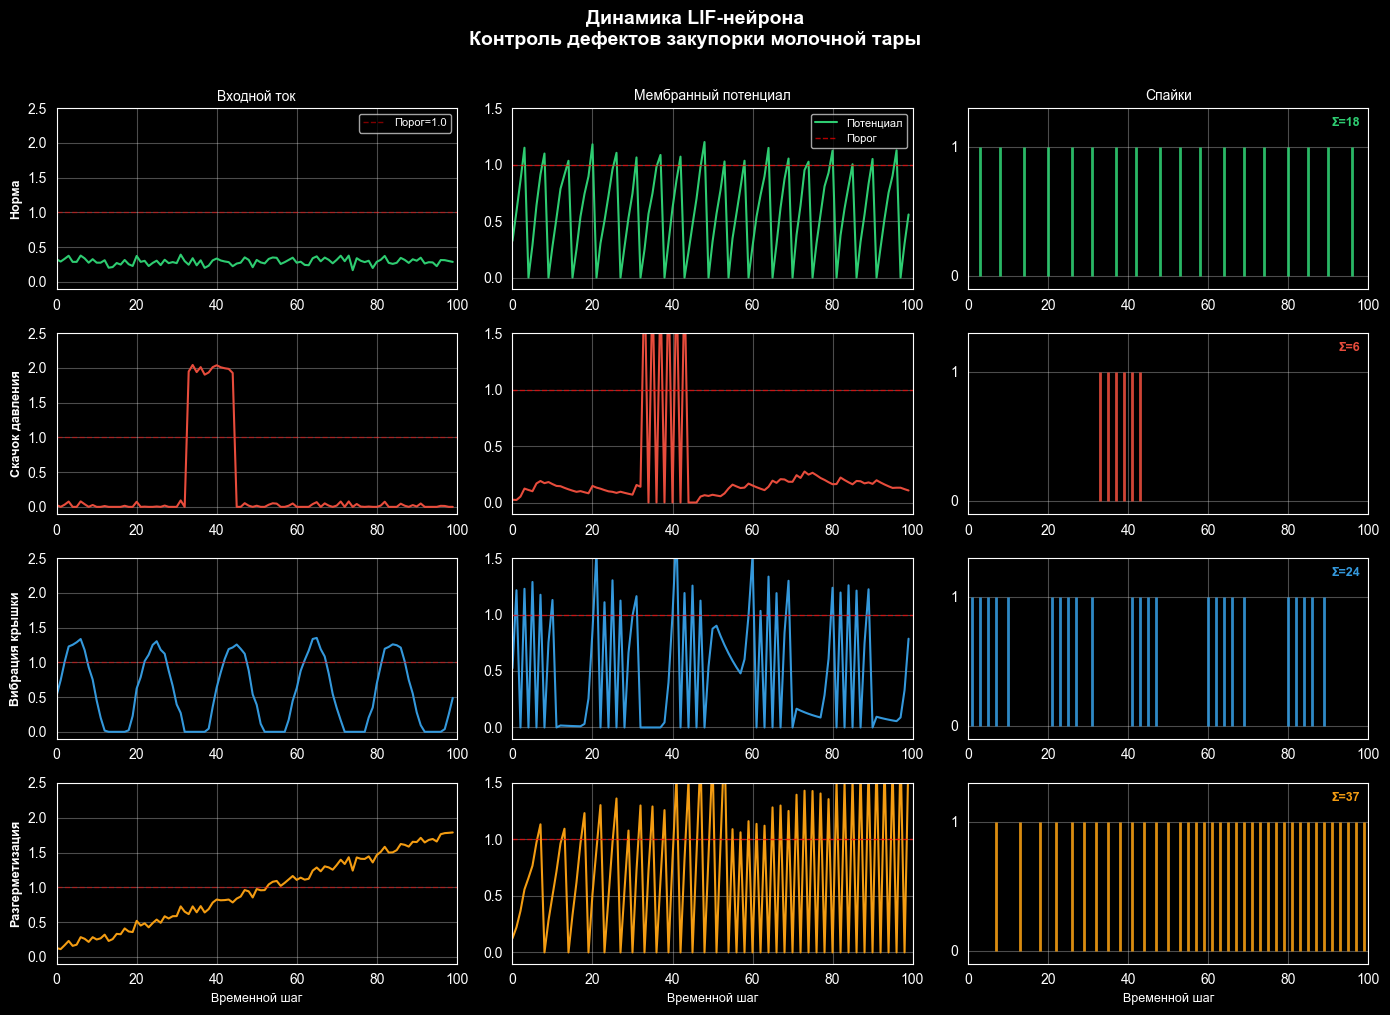

In [5]:
# Визуализация динамики
fig = plot_lif_dynamics(neuron)
plt.show()

**Наблюдения:**
- `normal`: стабильный сигнал → редкие спайки
- `pressure`: импульс → всплеск спайков в момент скачка
- `vibration`: периодический сигнал → регулярные спайки
- `leak`: нарастание → постепенное учащение спайков

---
## 2. Задача 3: SNN для классификации дефектов

In [ ]:
from src.snn.snn_classifier import (
    BottleDefectDataset, SNNDefectClassifier, SNNTrainer,
    CLASS_NAMES, plot_training_history
)
from torch.utils.data import DataLoader, random_split

# Синтетический датасет
dataset = BottleDefectDataset(
    num_samples=2000, num_classes=4,
    signal_length=64, noise_level=0.1, seed=42
)
print(f'Датасет: {len(dataset)} образцов')
print('Распределение классов:')
for class_id, count in dataset.get_class_distribution().items():
    print(f'  [{class_id}] {CLASS_NAMES[class_id]:<25} {count} образцов')

In [ ]:
from src.utils.visualization import plot_dataset_samples, plot_class_distribution

fig = plot_dataset_samples(dataset, num_per_class=3)
plt.show()

fig2 = plot_class_distribution(dataset)
plt.show()

In [ ]:
# Разбивка датасета
train_size = int(0.7 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

g = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size], generator=g)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64)
test_loader  = DataLoader(test_ds,  batch_size=64)

print(f'Train: {train_size} | Val: {val_size} | Test: {test_size}')

In [ ]:
# Создание и обучение SNN
snn_model = SNNDefectClassifier(
    input_size=64, hidden1=128, hidden2=64,
    num_classes=4, beta=0.9, num_timesteps=25
)
trainer = SNNTrainer(snn_model, device=DEVICE, lr=1e-3)

history = trainer.fit(train_loader, val_loader, num_epochs=20)

In [ ]:
# График обучения
fig = plot_training_history(history, title='История обучения SNN (дефекты закупорки)')
plt.show()

# Тестовые метрики
from sklearn.metrics import classification_report
preds, labels = trainer.predict(test_loader)
print('\nОтчёт по классификации (тест):')
print(classification_report(labels, preds, target_names=[CLASS_NAMES[i] for i in range(4)]))

In [ ]:
# Анализ спайков по классам
from src.utils.visualization import plot_spike_rate_analysis

fig = plot_spike_rate_analysis(snn_model, dataset, num_samples_per_class=50)
plt.show()

---
## 3. Задача 4: Сравнение SNN vs ANN

In [ ]:
from src.snn.comparison import SNNvsANNComparison

comparison = SNNvsANNComparison(
    num_samples=2000,
    signal_length=64,
    num_classes=4,
    num_epochs=20,
    batch_size=64,
    lr=1e-3,
    num_timesteps=25,
    seed=42,
)

results = comparison.run(verbose=True)

In [ ]:
# Итоговый дашборд сравнения
fig = comparison.plot_comparison()
plt.show()

---
## 4. Задача 5: Адаптация под специальность

### SNN как компонент ИС контроля дефектов закупорки

В контексте дипломной работы SNN может быть интегрирован в следующую пайплайн:

```
Датчики давления/вибрации
    ↓ (аналоговый сигнал)
АЦП (аналого-цифровой преобразователь)
    ↓ (временной ряд)
Rate Encoding → SNN классификатор
    ↓ (класс дефекта)
Система уведомлений / отбраковки
```

**Преимущества SNN для производственной линии:**
- Работа на нейроморфных чипах (Intel Loihi) → низкое энергопотребление
- Событийная обработка → малая задержка при обнаружении аномалии
- Естественная работа с временны́ми рядами датчиков

In [ ]:
# Демонстрация: классификация одного образца в реальном времени
import time

snn_model.eval()
snn_model.to(DEVICE)

print('Симуляция классификации сигналов датчика в реальном времени:')
print('=' * 60)

for sig_type, true_class in [('normal', 0), ('pressure', 1), ('vibration', 2), ('leak', 3)]:
    signal = generate_sensor_signal(sig_type, duration=64, seed=1)
    signal = signal.unsqueeze(0).to(DEVICE)  # [1, 64]
    
    t0 = time.perf_counter()
    with torch.no_grad():
        spike_counts, _ = snn_model(signal)
    latency = (time.perf_counter() - t0) * 1000
    
    pred_class = spike_counts.argmax(1).item()
    confidence = spike_counts[0, pred_class].item() / spike_counts.sum().item()
    
    status = '✓' if pred_class == true_class else '✗'
    print(f'{status} Сигнал: {sig_type:<12} | Предсказание: {CLASS_NAMES[pred_class]:<25} | '
          f'Уверенность: {confidence:.1%} | Задержка: {latency:.2f}мс')

---
## 5. Задача 6: Тесты

Для запуска тестов выполните в терминале:

```bash
cd week7/
pytest tests/test_snn.py -v
```

Тесты покрывают:
- Конфигурацию LIF-нейрона (валидация параметров)
- Формы выходных тензоров
- Бинарность спайков
- Свойства датасета
- Прямой проход SNN и ANN
- Smoke-тест обучения (1 эпоха)
- Определение устройства

---
## Итоги

| Компонент | Статус |
|-----------|--------|
| LIF-нейрон с динамикой | ✅ |
| Генерация сигналов датчиков | ✅ |
| SNN-классификатор (4 класса) | ✅ |
| Rate coding | ✅ |
| Сравнение SNN vs ANN | ✅ |
| Анализ энергоэффективности (SynOps) | ✅ |
| Визуализация спайков | ✅ |
| Адаптация под дефекты закупорки | ✅ |
| Тесты (25+) | ✅ |